Epoch 1/300
69/69 - 1s - 16ms/step - accuracy: 0.7581 - loss: 0.6656 - val_accuracy: 0.7899 - val_loss: 0.5026
Epoch 2/300
69/69 - 0s - 2ms/step - accuracy: 0.8162 - loss: 0.4301 - val_accuracy: 0.8167 - val_loss: 0.4270
Epoch 3/300
69/69 - 0s - 2ms/step - accuracy: 0.8407 - loss: 0.3722 - val_accuracy: 0.8439 - val_loss: 0.3745
Epoch 4/300
69/69 - 0s - 2ms/step - accuracy: 0.8522 - loss: 0.3476 - val_accuracy: 0.8580 - val_loss: 0.3449
Epoch 5/300
69/69 - 0s - 2ms/step - accuracy: 0.8679 - loss: 0.3180 - val_accuracy: 0.8580 - val_loss: 0.3310
Epoch 6/300
69/69 - 0s - 2ms/step - accuracy: 0.8678 - loss: 0.3132 - val_accuracy: 0.8693 - val_loss: 0.3187
Epoch 7/300
69/69 - 0s - 2ms/step - accuracy: 0.8759 - loss: 0.2973 - val_accuracy: 0.8711 - val_loss: 0.3128
Epoch 8/300
69/69 - 0s - 2ms/step - accuracy: 0.8815 - loss: 0.2890 - val_accuracy: 0.8643 - val_loss: 0.3245
Epoch 9/300
69/69 - 0s - 2ms/step - accuracy: 0.8830 - loss: 0.2776 - val_accuracy: 0.8734 - val_loss: 0.3087
Epoch 10/

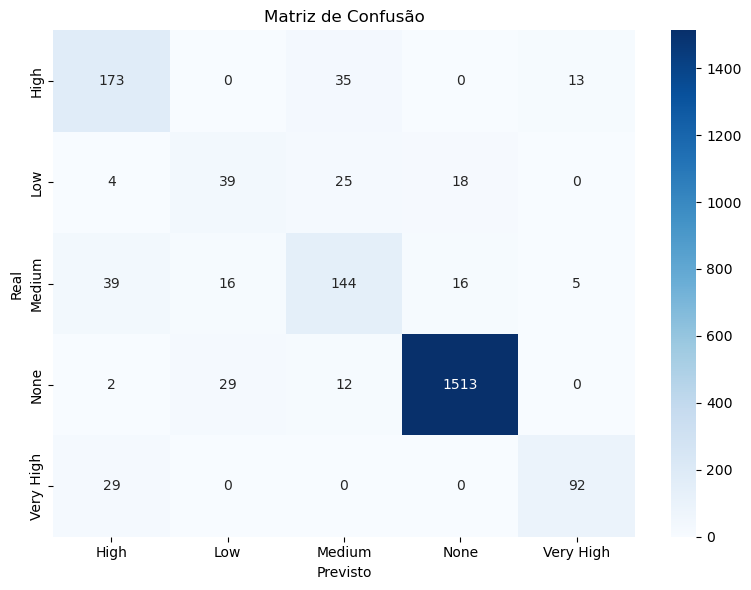

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 379us/step


In [3]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Preparação dos dados
energia_A = pd.read_csv('energia_202109-202112.csv', encoding='latin1')
energia_B = pd.read_csv('energia_202201-202212.csv', encoding='latin1')
meteo_A = pd.read_csv('meteo_202109-202112.csv', encoding='latin1')
meteo_B = pd.read_csv('meteo_202201-202212.csv', encoding='latin1')
energia = pd.concat([energia_A, energia_B], ignore_index=True)
meteo = pd.concat([meteo_A, meteo_B], ignore_index=True)

energia['timestamp'] = pd.to_datetime(energia['Data']) + pd.to_timedelta(energia['Hora'], unit='h')
meteo['dt_iso_clean'] = meteo['dt_iso'].str.replace(r' \+0000 UTC', '', regex=True)
meteo['timestamp'] = pd.to_datetime(meteo['dt_iso_clean'], format='%Y-%m-%d %H:%M:%S')

features_meteo = ['timestamp', 'temp', 'feels_like', 'temp_min', 'temp_max',
                  'pressure', 'humidity', 'wind_speed', 'rain_1h',
                  'clouds_all', 'weather_description']
df = pd.merge(energia, meteo[features_meteo], on='timestamp', how='left')
for col in ['temp','feels_like','temp_min','temp_max','pressure',
            'humidity','wind_speed','clouds_all']:
    df[col] = df[col].fillna(df[col].mean())
df['rain_1h'] = df['rain_1h'].fillna(0)
df['weather_description'] = df['weather_description'].fillna('missing')
df['Injeção na rede (kWh)'] = df['Injeção na rede (kWh)'].fillna('None')

# Feature engineering avançada
df['hour'] = df['timestamp'].dt.hour
df['dayofweek'] = df['timestamp'].dt.dayofweek
df['month'] = df['timestamp'].dt.month
df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df['temp_x_wind'] = df['temp'] * df['wind_speed']
df['autoc_x_temp'] = df['Autoconsumo (kWh)'] * df['temp']
df['prod_ratio'] = df['Autoconsumo (kWh)'] / (df['Normal (kWh)'] + 1)

numericas = [
    'temp', 'feels_like', 'temp_min', 'temp_max', 'pressure', 'humidity', 'wind_speed', 'clouds_all',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'temp_x_wind', 'autoc_x_temp', 'prod_ratio'
]

imputer = KNNImputer(n_neighbors=5)
df[numericas] = imputer.fit_transform(df[numericas])

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
weather_ohe = ohe.fit_transform(df[['weather_description']])
weather_ohe_df = pd.DataFrame(weather_ohe, columns=ohe.get_feature_names_out(['weather_description']))
df = pd.concat([df, weather_ohe_df], axis=1)
scaler = StandardScaler()
df[numericas] = scaler.fit_transform(df[numericas])

le_target = LabelEncoder()
df['y'] = le_target.fit_transform(df['Injeção na rede (kWh)'])
target_names = [str(c) for c in le_target.classes_]

final_features = [
    'Normal (kWh)', 'Horário Económico (kWh)', 'Autoconsumo (kWh)', 'hour', 'dayofweek', 'month', 'is_weekend'
] + numericas + list(weather_ohe_df.columns)

X = df[final_features].values
y = df['y'].values

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

n_classes = len(le_target.classes_)
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(n_classes, activation='softmax')
])
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
es = EarlyStopping(monitor='val_accuracy', patience=40, restore_best_weights=True)

history = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                    epochs=300, batch_size=128, callbacks=[es], verbose=2)

y_val_pred = np.argmax(model.predict(X_val), axis=1)
print('Accuracy:', accuracy_score(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred, target_names=target_names))

# Matriz de confusão (gráfico heatmap)
cm = confusion_matrix(y_val, y_val_pred, labels=np.arange(len(target_names)))
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.tight_layout()
plt.show()

# PREPARAÇÃO DOS DADOS DE TESTE
energia_test = pd.read_csv('energia_202301-202304.csv', encoding='latin1')
meteo_test = pd.read_csv('meteo_202301-202304.csv', encoding='latin1')
energia_test['timestamp'] = pd.to_datetime(energia_test['Data']) + pd.to_timedelta(energia_test['Hora'], unit='h')
meteo_test['dt_iso_clean'] = meteo_test['dt_iso'].str.replace(r' \+0000 UTC', '', regex=True)
meteo_test['timestamp'] = pd.to_datetime(meteo_test['dt_iso_clean'], format='%Y-%m-%d %H:%M:%S')
df_test = pd.merge(energia_test, meteo_test[features_meteo], on='timestamp', how='left')
df_test['hour'] = df_test['timestamp'].dt.hour
df_test['dayofweek'] = df_test['timestamp'].dt.dayofweek
df_test['month'] = df_test['timestamp'].dt.month
df_test['is_weekend'] = (df_test['dayofweek'] >= 5).astype(int)

# Criação das features derivadas EM PRIMEIRO LUGAR
df_test['hour_sin'] = np.sin(2 * np.pi * df_test['hour'] / 24)
df_test['hour_cos'] = np.cos(2 * np.pi * df_test['hour'] / 24)
df_test['month_sin'] = np.sin(2 * np.pi * df_test['month'] / 12)
df_test['month_cos'] = np.cos(2 * np.pi * df_test['month'] / 12)
df_test['temp_x_wind'] = df_test['temp'] * df_test['wind_speed']
df_test['autoc_x_temp'] = df_test['Autoconsumo (kWh)'] * df_test['temp']
df_test['prod_ratio'] = df_test['Autoconsumo (kWh)'] / (df_test['Normal (kWh)'] + 1)

for col in numericas:
    df_test[col] = df_test[col].fillna(df[col].mean())

df_test['rain_1h'] = df_test['rain_1h'].fillna(0)
df_test['weather_description'] = df_test['weather_description'].fillna('missing')

df_test[numericas] = imputer.transform(df_test[numericas])
df_test.loc[~df_test['weather_description'].isin(ohe.categories_[0]), 'weather_description'] = 'missing'
weather_ohe_test = ohe.transform(df_test[['weather_description']])
weather_ohe_df_test = pd.DataFrame(weather_ohe_test, columns=ohe.get_feature_names_out(['weather_description']))
df_test = pd.concat([df_test, weather_ohe_df_test], axis=1)
df_test[numericas] = scaler.transform(df_test[numericas])
X_test = df_test[final_features].values

y_pred_test = np.argmax(model.predict(X_test), axis=1)
labels_pred = le_target.inverse_transform(y_pred_test)
dummy = pd.read_csv('dummy_submission.csv')
assert len(dummy) == len(labels_pred)
dummy['Result'] = labels_pred
dummy.to_csv('submission.csv', index=False)


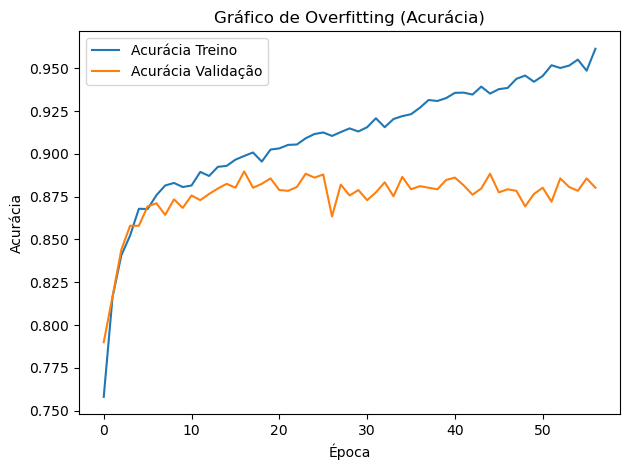

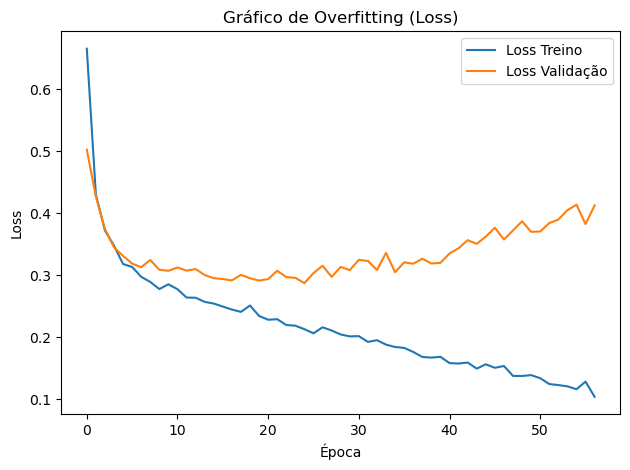

In [4]:
plt.plot(history.history['accuracy'], label='Acurácia Treino')
plt.plot(history.history['val_accuracy'], label='Acurácia Validação')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.title('Gráfico de Overfitting (Acurácia)')
plt.legend()
plt.tight_layout()
plt.show()

plt.plot(history.history['loss'], label='Loss Treino')
plt.plot(history.history['val_loss'], label='Loss Validação')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.title('Gráfico de Overfitting (Loss)')
plt.legend()
plt.tight_layout()
plt.show()


Modelo: Keras com Early Stopping
Modelo acerta melhor nas classes dominantes e com muitos exemplos (“None”).

“Low” e “Very High” são frequentemente previstas como “Medium” ou “High”, sugerindo que o modelo tem dificuldade em distinguir estas classes